In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json
import sxs

plt.style.use("../MATPLOTLIB_RCPARAMS.sty")

In [3]:
with open("QNM_results.json") as input_file:
    data = json.load(input_file)

In [4]:
def chi_p(chi1, chi2, q):

    L_hat = np.array([0, 0, 1])  
    
    chi1_perp = np.linalg.norm(np.cross(chi1, L_hat))
    chi2_perp = np.linalg.norm(np.cross(chi2, L_hat))
    
    factor = (3 + 4 * q) / (4 + 3 * q)
    chi_p = max(chi1_perp, factor * chi2_perp)
    
    return chi_p 


def chi_eff(chi1, chi2, q):
    return (q*chi1[2] + chi2[2]) / (1+q)


In [5]:
modes = [(2, 2), (2, 1), (3, 3), (3, 2), (3, 1)]
ratios = {}
diffs = {}
vs = {}
phis = {}
chi_ps = {}
chi_effs = {}
qs = {}
chi1s = {}
chi2s = {}

for mode in modes:
    l, m = mode
    for id_ in data.keys():  
        key_pos = f"({l},{m},0,1)"
        key_neg = f"({l},{-m},0,-1)"
        
        ampl_pos = np.linalg.norm(data[id_][key_pos]['A'])
        ampl_neg = np.linalg.norm(data[id_][key_neg]['A']) 
        ratio = ampl_pos / ampl_neg
        diff = np.abs(data[id_][key_pos]['A'][0] + 1j*data[id_][key_pos]['A'][1] 
                      - (-1)**l * data[id_][key_neg]['A'][0] + 1j*data[id_][key_neg]['A'][1])
        
        ratios[(id_, l, m)] = ratio
        diffs[(id_, l, m)] = diff
        vs[id_] = data[id_]["kick rapidity"]
        phis[id_] = data[id_]["kick theta"]
        chi_ps[id_] = chi_p(data[id_]["chi1"], data[id_]["chi2"], data[id_]["q"])
        chi_effs[id_] = chi_eff(data[id_]["chi1"], data[id_]["chi2"], data[id_]["q"])
        chi1s[id_] = data[id_]["chi1"]
        chi2s[id_] = data[id_]["chi2"]
        qs[id_] = data[id_]["q"]

In [6]:
with open("sxs_qnm_matches.json") as input_file:
    Zhu_to_SXS = json.load(input_file)

In [7]:
def h_copr_from_sxs(sxs_id):

    # load sxs waveform object with truncation of junk and time shift
    sxs_bbh = sxs.load(sxs_id)
    wf = sxs_bbh.h
    time = wf.t 
    t_peak = wf.max_norm_time()
    t_ref = sxs_bbh.metadata.reference_time 
    idx_ref = wf.index_closest_to(t_ref) 
    wf = wf[idx_ref:]
    time = time[idx_ref:] - t_peak

    # frame transformation and mode dict building
    wf_copr = wf.to_coprecessing_frame()
    data_copr = wf_copr.data.T 
    mode_list = [(ell,m) for ell in range(wf.ell_min, wf.ell_max + 1) for m in range(-ell,ell+1)]
    h_copr = dict(zip(mode_list, data_copr))

    return h_copr 


#-----------------------------------------------------------------------------------------------------


def h_iner_from_sxs(sxs_id):

    sxs_bbh = sxs.load(sxs_id)
    wf = sxs_bbh.h
    data = wf.data.T 
    mode_list = [(ell,m) for ell in range(wf.ell_min, wf.ell_max + 1) for m in range(-ell,ell+1)]
    h_iner = dict(zip(mode_list, data))

    return h_iner 


#-----------------------------------------------------------------------------------------------------


def h_minus(h, l, m):
    '''
    Returns the anti-symmetric waveform 
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    return (h[(l,m)] - (-1)**l * np.conjugate(h[(l,-m)]))/2


#-----------------------------------------------------------------------------------------------------


def a_minus_hat(h, l, m):
    '''
    Returns the amplitude of the anti-symmetric waveform
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    a = np.abs(h_minus(h, l, m)) 
    return np.max(a)


In [19]:
ampl_asym_copr = {}

for id_ in Zhu_to_SXS.keys():  
    sxs_id = Zhu_to_SXS[id_]
    h_copr = h_copr_from_sxs(sxs_id)
    for mode in modes:
        l, m = mode
        ampl_peak = a_minus_hat(h_copr, l, m)
        ampl_asym_copr[(id_, l, m)] = ampl_peak

In [11]:
ampl_asym_iner = {}

for id_ in Zhu_to_SXS.keys():  
    sxs_id = Zhu_to_SXS[id_]
    h_iner = h_iner_from_sxs(sxs_id)
    for mode in modes:
        l, m = mode
        ampl_peak = a_minus_hat(h_iner, l, m)
        ampl_asym_iner[(id_, l, m)] = ampl_peak

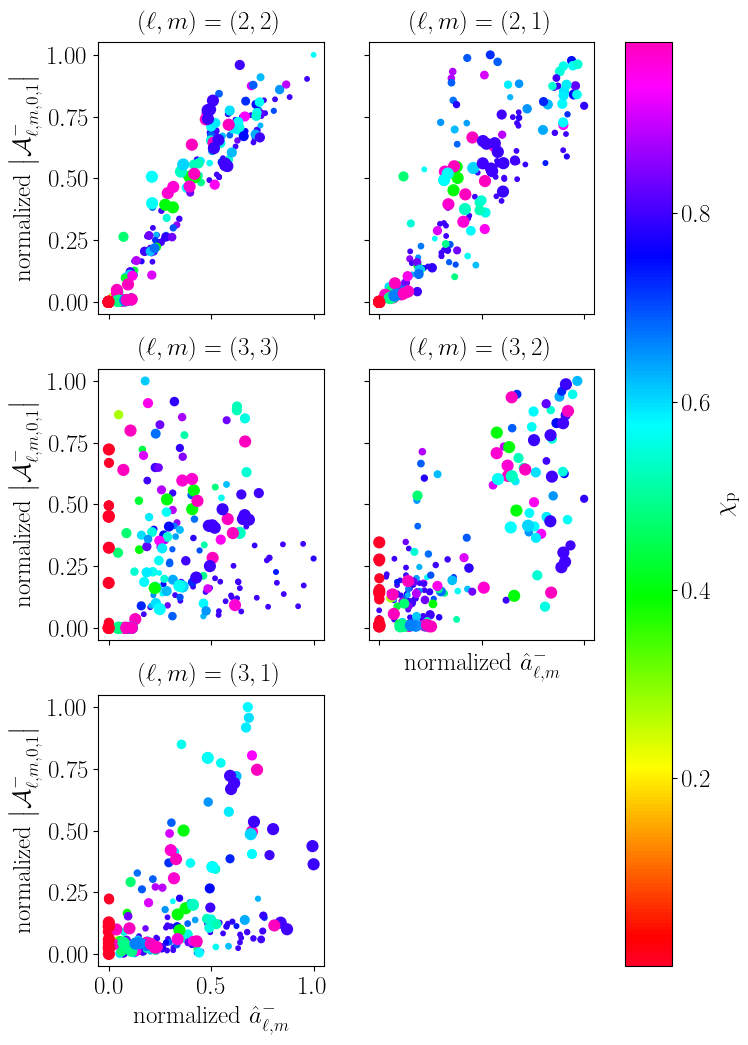

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(8, 12), sharex=True, sharey=True)
axs = axs.flatten()

for i, (ell, m) in enumerate(modes):
    x = [] 
    y = []  
    c = [] 
    s = []
    for id_ in Zhu_to_SXS.keys():
        x.append(ampl_asym_iner[id_, ell, m]/np.max([ampl_asym_iner[id_, ell, m] for id_ in Zhu_to_SXS.keys()]))
        y.append(diffs[(id_, ell, m)]/np.max([diffs[(id_, ell, m)] for id_ in Zhu_to_SXS.keys()]))
        c.append(chi_ps[id_])
        s.append(qs[id_]*10)

    sc = axs[i].scatter(x, y, c=c, cmap='gist_rainbow', s=s)
    axs[i].text(0.5, 1.075, r"$(\ell,m) = (%s,%s)$" % (ell,m),
            ha='center', va='center',
            transform=axs[i].transAxes,
            color='black')


axs[0].set_ylabel(r'normalized $\big|\mathcal{A}^-_{\ell, m, 0, 1}\big|$')
axs[2].set_ylabel(r'normalized $\big|\mathcal{A}^-_{\ell, m, 0, 1}\big|$')
axs[4].set_ylabel(r'normalized $\big|\mathcal{A}^-_{\ell, m, 0, 1}\big|$')
axs[3].set_xlabel(r"normalized $\hat{a}^-_{\ell,m}$")
axs[4].set_xlabel(r"normalized $\hat{a}^-_{\ell,m}$")
if len(modes) < len(axs):
    axs[-1].axis("off")

cbar = fig.colorbar(sc, ax=axs.ravel().tolist())
cbar.set_label(r"$\chi_{\text{p}}$")

# plt.savefig('asym_rd_ampls_asym_peak_chip.pdf')
plt.show()